Binshah Joseph
Reg no: 22149
Project: Pneumonia Detection
Submitted to: Mam Tahira Kanwal
DEPT: BSCS 7th Semester

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/Pneumonia_Project'))

['archive (1).zip']


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/Pneumonia_Project/archive (1).zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
print(os.listdir('/content'))

['.config', 'drive', 'chest_xray', 'sample_data']


In [ ]:
print(os.listdir('/content/chest_xray'))

['val', '__MACOSX', 'test', 'chest_xray', 'train']


In [ ]:
print(os.listdir('/content/chest_xray/train'))

['PNEUMONIA', 'NORMAL']


In [ ]:
import tensorflow as tf          //tensorflorw ensure deep learning
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt             //evaluate calculation
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [ ]:
train_dir = "/content/chest_xray/train"
test_dir = "/content/chest_xray/test"
val_dir = "/content/chest_xray/val"

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(          //function call
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 4173 images belonging to 2 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1043 images belonging to 2 classes.


In [ ]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


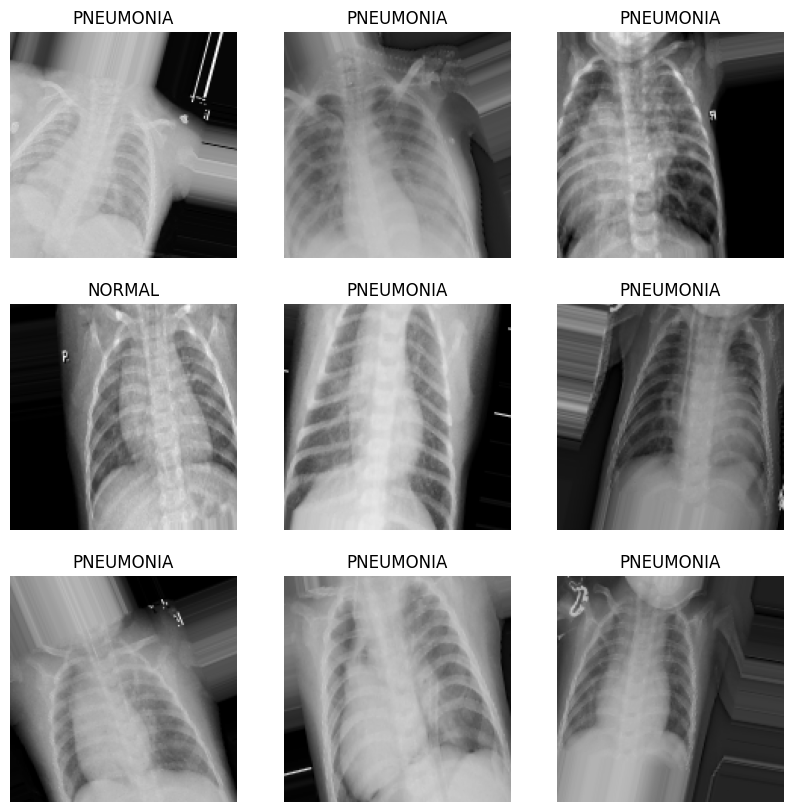

In [ ]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i]==1 else "NORMAL")
    plt.axis('off')

plt.show()

In [ ]:
from tensorflow.keras.models import Sequential          //CNN MODEL
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(64,activation='relu'),

    Dropout(0.6),

    Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 600ms/step - accuracy: 0.7795 - loss: 0.5902 - val_accuracy: 0.7430 - val_loss: 14.8390
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 71s 543ms/step - accuracy: 0.7939 - loss: 0.4050 - val_accuracy: 0.7430 - val_loss: 25.8193
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 72s 550ms/step - accuracy: 0.8001 - loss: 0.3740 - val_accuracy: 0.7430 - val_loss: 27.5989
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 72s 551ms/step - accuracy: 0.8150 - loss: 0.3735 - val_accuracy: 0.7459 - val_loss: 3.9503
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 74s 563ms/step - accuracy: 0.8335 - loss: 0.3193 - val_accuracy: 0.7430 - val_loss: 15.3388
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 74s 561ms/step - accuracy: 0.8303 - loss: 0.3543 - val_accuracy: 0.7929 - val_loss: 0.4203
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 73s 561ms/step - accuracy: 0.8565 - loss: 0.3263 - val_accuracy: 0.4161 - val_loss: 0.7787
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 73s 556ms/step - accuracy: 0.8632 - los

In [ ]:
model.save("pneumonia_cnn_model.h5")

print("Model Saved")

Model Saved


In [ ]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 303ms/step - accuracy: 0.7436 - loss: 0.5110
Test Accuracy: 0.7435897588729858
Test Loss: 0.5109706521034241


In [ ]:
history.history['accuracy']
history.history['val_accuracy']
history.history['loss']
history.history['val_loss']

[14.838967323303223,
 25.819263458251953,
 27.598947525024414,
 3.9502856731414795,
 15.338830947875977,
 0.420335054397583,
 0.7787141799926758,
 0.7024198770523071,
 0.5808593034744263]

In [ ]:
print("Training Accuracy:", history.history['accuracy'])
print("Validation Accuracy:", history.history['val_accuracy'])

print("Training Loss:", history.history['loss'])
print("Validation Loss:", history.history['val_loss'])

Training Accuracy: [0.7795351147651672, 0.7939132452011108, 0.8001437783241272, 0.8150011897087097, 0.8334531784057617, 0.8303378820419312, 0.8564581871032715, 0.8631680011749268, 0.8768272399902344]
Validation Accuracy: [0.743048906326294, 0.743048906326294, 0.743048906326294, 0.7459251880645752, 0.743048906326294, 0.7929050922393799, 0.4161073863506317, 0.5752636790275574, 0.8072866797447205]
Training Loss: [0.5901590585708618, 0.405000239610672, 0.37397482991218567, 0.3734602928161621, 0.3193165063858032, 0.35433733463287354, 0.32628384232521057, 0.3136066794395447, 0.29242801666259766]
Validation Loss: [14.838967323303223, 25.819263458251953, 27.598947525024414, 3.9502856731414795, 15.338830947875977, 0.420335054397583, 0.7787141799926758, 0.7024198770523071, 0.5808593034744263]


In [ ]:
import os

normal_count = len(os.listdir('/content/chest_xray/train/NORMAL'))
pneumonia_count = len(os.listdir('/content/chest_xray/train/PNEUMONIA'))

print("NORMAL Images:", normal_count)
print("PNEUMONIA Images:", pneumonia_count)

NORMAL Images: 1341
PNEUMONIA Images: 3875


In [ ]:
normal_count = len(os.listdir('/content/chest_xray/train/NORMAL'))
pneumonia_count = len(os.listdir('/content/chest_xray/train/PNEUMONIA'))

print(normal_count)
print(pneumonia_count)

1341
3875


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [ ]:
print(class_weights)

{0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [ ]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - accuracy: 0.7436 - loss: 0.5110
Test Accuracy: 0.7435897588729858
Test Loss: 0.5109706521034241


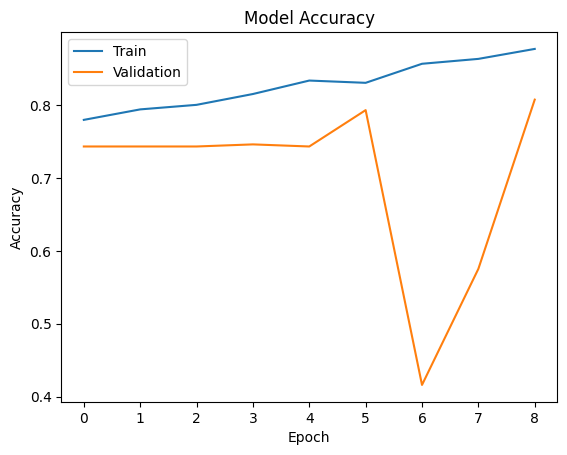

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

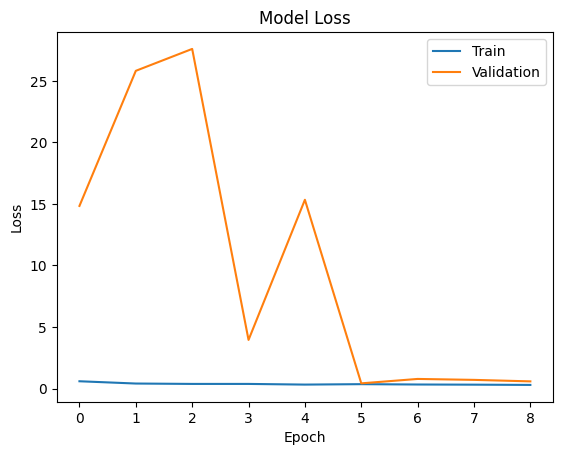

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Validation'])

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(test_generator.classes, y_pred)

print(cm)

20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 417ms/step
[[221  13]
 [147 243]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_generator.classes,
        y_pred,
        target_names=['NORMAL','PNEUMONIA']
    )
)

              precision    recall  f1-score   support

      NORMAL       0.60      0.94      0.73       234
   PNEUMONIA       0.95      0.62      0.75       390

    accuracy                           0.74       624
   macro avg       0.77      0.78      0.74       624
weighted avg       0.82      0.74      0.75       624



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


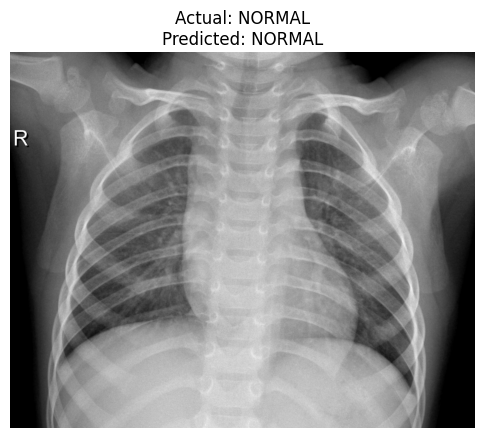

Image: NORMAL2-IM-0352-0001.jpeg
Actual Class: NORMAL
Predicted Class: NORMAL
Prediction Score: 0.3277923


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Randomly choose class
class_name = random.choice(['NORMAL', 'PNEUMONIA'])

# Folder path
folder_path = f'/content/chest_xray/test/{class_name}'

# Random image from folder
img_name = random.choice(os.listdir(folder_path))
img_path = os.path.join(folder_path, img_name)

# Load image for prediction
img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

predicted_class = "PNEUMONIA" if prediction[0][0] > 0.5 else "NORMAL"

# Display image
plt.figure(figsize=(6,6))
plt.imshow(image.load_img(img_path))
plt.axis('off')
plt.title(f"Actual: {class_name}\nPredicted: {predicted_class}")
plt.show()

print("Image:", img_name)
print("Actual Class:", class_name)
print("Predicted Class:", predicted_class)
print("Prediction Score:", prediction[0][0])

In [ ]:
history.history

{'accuracy': [0.7795351147651672,
  0.7939132452011108,
  0.8001437783241272,
  0.8150011897087097,
  0.8334531784057617,
  0.8303378820419312,
  0.8564581871032715,
  0.8631680011749268,
  0.8768272399902344],
 'loss': [0.5901590585708618,
  0.405000239610672,
  0.37397482991218567,
  0.3734602928161621,
  0.3193165063858032,
  0.35433733463287354,
  0.32628384232521057,
  0.3136066794395447,
  0.29242801666259766],
 'val_accuracy': [0.743048906326294,
  0.743048906326294,
  0.743048906326294,
  0.7459251880645752,
  0.743048906326294,
  0.7929050922393799,
  0.4161073863506317,
  0.5752636790275574,
  0.8072866797447205],
 'val_loss': [14.838967323303223,
  25.819263458251953,
  27.598947525024414,
  3.9502856731414795,
  15.338830947875977,
  0.420335054397583,
  0.7787141799926758,
  0.7024198770523071,
  0.5808593034744263]}

In [ ]:
print("Training Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

print("Training Loss:", history.history['loss'][-1])
print("Validation Loss:", history.history['val_loss'][-1])

Training Accuracy: 0.8768272399902344
Validation Accuracy: 0.8072866797447205
Training Loss: 0.29242801666259766
Validation Loss: 0.5808593034744263
